In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [2]:
from matplotlib import rcParams, font_manager
font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'  # Replace with the actual path
rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()

In [3]:
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'
fm.fontManager.addfont(font_path)  # Only if you're adding a new font file
fm._load_fontmanager(try_read_cache=False)

In [4]:
# Load Gene Weights
ASD_Hiq_GW_NoMutTypeDiff = Fil2Dict("../dat/GeneWeights/HIQ.top61.nopLI.LGD_Dmis_SameWeight.gw")
SCZ_GW_NoMutTypeDiff_Mis2 = Fil2Dict("../dat/GeneWeights/SCZ.top61.nopLI.LGD_Dmis_SameWeight.exclude_Mis2.gw") 

In [5]:
#ASD_GW = ASD_Hiq_GW
ASD_GW = ASD_Hiq_GW_NoMutTypeDiff
SCZ_GW = SCZ_GW_NoMutTypeDiff_Mis2

In [6]:
#HCT_Z2_MAT_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/Human.Cluster.Log2Mean.Z1clip5.Z2.clip3.Dec30.csv", index_col=0)
#HCT_Z2_MAT_HCT = pd.read_csv("/home/jw3514/Work/UNIMED/TDEP-sLDSC/data/cluster.specificity_matrix_entrez_percentile.csv", index_col=0)
#HCT_Z2_MAT_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/Test.BiasMat/HumanCT.Spec.clip.noLowExp.cut1e4.csv", index_col=0)
HCT_Z2_MAT_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/HumanCT.TPM.0.1.Filt.Spec.clip.lowexp.cut1e4.csv", index_col=0)
HumanCT_Z2_HCT_ColMean = HCT_Z2_MAT_HCT.mean(axis=0)‘’
HCT_Z2_MAT_HCT.columns = HCT_Z2_MAT_HCT.columns.astype(int)

In [7]:
tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, ASD_GW)
tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, SCZ_GW)
tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)

r,p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, efflabel="EFFECT", CTs = Neur_idx)
print(r,p)

0.6798814970045978 1.3524128077417056e-52


## Load gnomad data

In [8]:
gnomad4 = pd.read_csv("/home/jw3514/Work/data/gnomad/gnomad.v4.0.constraint_metrics.tsv", sep="\t")
search_text = 'ENST'
gnomad4 = gnomad4[(gnomad4["transcript"].str.contains(search_text))]
gnomad4 = gnomad4[gnomad4["mane_select"]==True]
for i, row in gnomad4.iterrows():
    symbol = row["gene"]
    gnomad4.loc[i, "Entrez"] = int(GeneSymbol2Entrez.get(symbol, 0))
gnomad4 = gnomad4[gnomad4["Entrez"]!=0]

gnomad4 = gnomad4[["Entrez", "gene", "transcript", "lof_hc_lc.obs", "lof_hc_lc.exp", 
                   "lof.pLI", "lof.z_score", "mis.z_score"]]
gnomad4_lofz_rank = gnomad4.sort_values("lof.z_score", ascending=False)
gnomad4_lofz_rank["Entrez"] = gnomad4_lofz_rank["Entrez"].astype('int')

In [9]:
gnomad4 = pd.read_csv("/home/jw3514/Work/data/gnomad/gnomad.v4.0.constraint_metrics.tsv", sep="\t")
search_text = 'ENST'
gnomad4 = gnomad4[(gnomad4["transcript"].str.contains(search_text))]
gnomad4 = gnomad4[gnomad4["mane_select"]==True]
for i, row in gnomad4.iterrows():
    symbol = row["gene"]
    gnomad4.loc[i, "Entrez"] = int(GeneSymbol2Entrez.get(symbol, 0))

In [10]:
# Find genes in ASD_GW or SCZ_GW but not in gnomad4_lofz_rank
ASD_missing = set(ASD_GW.keys()) - set(gnomad4_lofz_rank["Entrez"])
SCZ_missing = set(SCZ_GW.keys()) - set(gnomad4_lofz_rank["Entrez"])

print("ASD genes not in gnomad4_lofz_rank:", len(ASD_missing))
print("SCZ genes not in gnomad4_lofz_rank:", len(SCZ_missing))

Missing_Symbols_G4 = []
print("\nMissing ASD genes:")
for gene in ASD_missing:
    print(gene, Entrez2Symbol[gene])
    Missing_Symbols_G4.append(Entrez2Symbol[gene])

print("\nMissing SCZ genes:")
for gene in SCZ_missing:
    print(gene, Entrez2Symbol[gene])
    Missing_Symbols_G4.append(Entrez2Symbol[gene])
# Original filtering
#ASD_GeneLofZ = gnomad4_lofz_rank[gnomad4_lofz_rank["Entrez"].isin(ASD_GW.keys())]
#SCZ_GeneLofZ = gnomad4_lofz_rank[gnomad4_lofz_rank["Entrez"].isin(SCZ_GW.keys())]

ASD genes not in gnomad4_lofz_rank: 1
SCZ genes not in gnomad4_lofz_rank: 5

Missing ASD genes:
4204 MECP2

Missing SCZ genes:
203427 SLC25A43
2892 GRIA3
1968 EIF2S3
81300 OR4P4
9947 MAGEC1


In [11]:
gnomad4 = pd.read_csv("/home/jw3514/Work/data/gnomad/gnomad.v4.0.constraint_metrics.tsv", sep="\t")
search_text = 'ENST'
gnomad4 = gnomad4[(gnomad4["transcript"].str.contains(search_text))]
gnomad4 = gnomad4[gnomad4["mane_select"]==True]
for i, row in gnomad4.iterrows():
    symbol = row["gene"]
    gnomad4.loc[i, "Entrez"] = int(GeneSymbol2Entrez.get(symbol, 0))
gnomad4 = gnomad4[gnomad4["Entrez"]!=0]

gnomad2 = pd.read_csv("/home/jw3514/Work/data/gnomad/gnomad.v2.1.1.lof_metrics.by_gene.txt", sep="\t")
for i, row in gnomad2.iterrows():
    symbol = row["gene"]
    gnomad2.loc[i, "Entrez"] = int(GeneSymbol2Entrez.get(symbol, 0))

<Axes: >

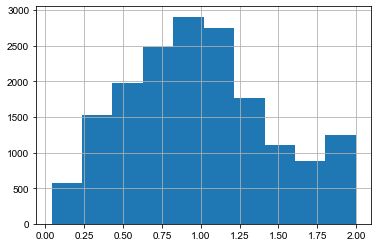

In [12]:
gnomad4["lof.oe_ci.upper"].hist()

<Axes: >

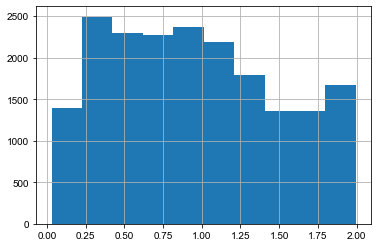

In [13]:
gnomad2["oe_lof_upper"].hist()

In [14]:
# Find genes in ASD_GW or SCZ_GW but not in gnomad4_lofz_rank
ASD_missing = set(ASD_GW.keys()) - set(gnomad2["Entrez"])
SCZ_missing = set(SCZ_GW.keys()) - set(gnomad2["Entrez"])

print("ASD genes not in gnomad4_lofz_rank:", len(ASD_missing))
print("SCZ genes not in gnomad4_lofz_rank:", len(SCZ_missing))

Missing_Symbols_G2 = []
print("\nMissing ASD genes:")
for gene in ASD_missing:
    print(gene, Entrez2Symbol[gene])
    Missing_Symbols_G2.append(Entrez2Symbol[gene])

print("\nMissing SCZ genes:")
for gene in SCZ_missing:
    print(gene, Entrez2Symbol[gene])
    Missing_Symbols_G2.append(Entrez2Symbol[gene])
# Original filtering
#ASD_GeneLofZ = gnomad4_lofz_rank[gnomad4_lofz_rank["Entrez"].isin(ASD_GW.keys())]
#SCZ_GeneLofZ = gnomad4_lofz_rank[gnomad4_lofz_rank["Entrez"].isin(SCZ_GW.keys())]


ASD genes not in gnomad4_lofz_rank: 1
SCZ genes not in gnomad4_lofz_rank: 3

Missing ASD genes:
51111 KMT5B

Missing SCZ genes:
3008 H1-4
399909 PCNX3
55719 SLF2


In [15]:
columns_to_keep_g2 = ["Entrez", "gene", "pLI", "lof_z", "oe_lof_upper"]
columns_to_keep_g4 = ["Entrez", "gene", "lof.pLI", "lof.z_score", "lof.oe_ci.upper"]
gnomad2 = gnomad2[columns_to_keep_g2]
gnomad4 = gnomad4[columns_to_keep_g4]
gnomad2.columns = columns_to_keep_g4


In [16]:
ASD_missing = set(ASD_GW.keys()) - set(gnomad4["Entrez"])
SCZ_missing = set(SCZ_GW.keys()) - set(gnomad4["Entrez"])

print("ASD genes not in gnomad4_lofz_rank:", len(ASD_missing))
print("SCZ genes not in gnomad4_lofz_rank:", len(SCZ_missing))

Missing_Symbols_G4 = []
print("\nMissing ASD genes:")
for gene in ASD_missing:
    print(gene, Entrez2Symbol[gene])
    Missing_Symbols_G4.append(Entrez2Symbol[gene])

print("\nMissing SCZ genes:")
for gene in SCZ_missing:
    print(gene, Entrez2Symbol[gene])
    Missing_Symbols_G4.append(Entrez2Symbol[gene])

ASD genes not in gnomad4_lofz_rank: 1
SCZ genes not in gnomad4_lofz_rank: 5

Missing ASD genes:
4204 MECP2

Missing SCZ genes:
203427 SLC25A43
2892 GRIA3
1968 EIF2S3
81300 OR4P4
9947 MAGEC1


In [17]:
for gene in Missing_Symbols_G4:
    if gene in gnomad2["gene"].values:
        row = gnomad2[gnomad2["gene"]==gene]
        gnomad4 = gnomad4.append(row, ignore_index=True)

/tmp/ipykernel_594726/1600708724.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  gnomad4 = gnomad4.append(row, ignore_index=True)


In [18]:
ASD_missing = set(ASD_GW.keys()) - set(gnomad4["Entrez"])
SCZ_missing = set(SCZ_GW.keys()) - set(gnomad4["Entrez"])

print("ASD genes not in gnomad4_lofz_rank:", len(ASD_missing))
print("SCZ genes not in gnomad4_lofz_rank:", len(SCZ_missing))

print("\nMissing ASD genes:")
for gene in ASD_missing:
    print(gene)

print("\nMissing SCZ genes:")
for gene in SCZ_missing:
    print(gene)

ASD genes not in gnomad4_lofz_rank: 0
SCZ genes not in gnomad4_lofz_rank: 0

Missing ASD genes:

Missing SCZ genes:


In [19]:
gnomad4_lofz_rank = gnomad4.sort_values("lof.z_score", ascending=False)
gnomad4_lofz_rank["Entrez"] = gnomad4_lofz_rank["Entrez"].astype('int')

In [20]:
BrainSpan = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat2/ExpMatch/BrainSpan.MatchDF.csv", index_col=0)
HumanSC = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat2/ExpMatch/HumanCT.MatchDF.csv", index_col=0)

In [21]:
ASD_GeneLofZ = gnomad4_lofz_rank[gnomad4_lofz_rank["Entrez"].isin(ASD_GW.keys())]
SCZ_GeneLofZ = gnomad4_lofz_rank[gnomad4_lofz_rank["Entrez"].isin(SCZ_GW.keys())]

In [22]:
# Annotate GW n Partition according to pLI

# For ASD_GeneLofZ
ASD_GeneLofZ = ASD_GeneLofZ.copy()
ASD_GeneLofZ["GW"] = ASD_GeneLofZ["Entrez"].map(ASD_GW)
ASD_GeneLofZ["BrainSpan"] = ASD_GeneLofZ["Entrez"].map(lambda x: BrainSpan.loc[x, "WB"] if x in BrainSpan.index else -1)
ASD_GeneLofZ["HumanCTExp"] = ASD_GeneLofZ["Entrez"].map(lambda x: HumanSC.loc[x, "Exp"] if x in HumanSC.index else 0)

# For SCZ_GeneLofZ
SCZ_GeneLofZ = SCZ_GeneLofZ.copy()
SCZ_GeneLofZ["GW"] = SCZ_GeneLofZ["Entrez"].map(SCZ_GW)
SCZ_GeneLofZ["BrainSpan"] = SCZ_GeneLofZ["Entrez"].map(lambda x: BrainSpan.loc[x, "WB"] if x in BrainSpan.index else -1)
SCZ_GeneLofZ["HumanCTExp"] = SCZ_GeneLofZ["Entrez"].map(lambda x: HumanSC.loc[x, "Exp"] if x in HumanSC.index else 0)

In [23]:
ASD_GeneLofZ.head(2)

,Entrez,gene,lof.pLI,lof.z_score,lof.oe_ci.upper,GW,BrainSpan,HumanCTExp
4291,1778,DYNC1H1,1.0,17.989,0.117,2,5.590113,9.636294e+06
7630,4297,KMT2A,1.0,14.445,0.065,1,2.087176,1.272627e+07


In [24]:
SCZ_GeneLofZ.head(2)

,Entrez,gene,lof.pLI,lof.z_score,lof.oe_ci.upper,GW,BrainSpan,HumanCTExp
10693,27445,PCLO,1.0,13.621,0.191,15.016954,2.773615,4.203083e+07
6423,8925,HERC1,1.0,13.039,0.330,20.027126,3.243137,2.602141e+07


In [25]:
ASD_GeneHumanExp = ASD_GeneLofZ.sort_values("HumanCTExp", ascending=False)
SCZ_GeneHumanExp = SCZ_GeneLofZ.sort_values("HumanCTExp", ascending=False)

In [26]:
ASD_GeneHumanExp.head(2)

,Entrez,gene,lof.pLI,lof.z_score,lof.oe_ci.upper,GW,BrainSpan,HumanCTExp
638,287,ANK2,1.0,12.4240,0.271,5,5.008495,8.799958e+07
6101,2904,GRIN2B,1.0,8.1812,0.102,1,1.722094,5.068329e+07


In [27]:
ASD_Gene_LOUEF = ASD_GeneLofZ.sort_values("lof.oe_ci.upper", ascending=False)
SCZ_Gene_LOUEF = SCZ_GeneLofZ.sort_values("lof.oe_ci.upper", ascending=False)

In [28]:
ASD_GeneLofZ.to_csv("../dat/Other/ASD_GeneLofZ.LGD_Dmis_SameWeight.csv", index=False)
SCZ_GeneLofZ.to_csv("../dat/Other/SCZ_GeneLofZ.LGD_Dmis_SameWeight.csv", index=False)

## Gradually remove Genes ranked by pLI/LOFZ/LUOF score vs random genes, how correlation change?

In [29]:
# Calculate correlation as genes are removed, sorted by LofZ (descending)
X_LofZ, Y_LofZ = [], []
for i in range(0, 31):
    tmp_ASD_GW = dict(zip(ASD_GeneLofZ["Entrez"].values[i:], ASD_GeneLofZ["GW"].values[i:]))
    tmp_SCZ_GW = dict(zip(SCZ_GeneLofZ["Entrez"].values[i:], SCZ_GeneLofZ["GW"].values[i:]))
    
    tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW)
    tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

    tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
    tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)
    
    r, p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, efflabel="EFFECT", CTs=Neur_idx)
    
    X_LofZ.append(i)
    Y_LofZ.append(r)

# Calculate correlation as genes are removed, sorted by LofZ (ascending)
Y_LofZ_rev = []
for i in range(0, 31):
    tmp_ASD_GW = dict(zip(ASD_GeneLofZ["Entrez"].values[::-1][i:], ASD_GeneLofZ["GW"].values[::-1][i:]))
    tmp_SCZ_GW = dict(zip(SCZ_GeneLofZ["Entrez"].values[::-1][i:], SCZ_GeneLofZ["GW"].values[::-1][i:]))
    
    tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW)
    tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

    tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
    tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)
    
    r, p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, efflabel="EFFECT", CTs=Neur_idx)

    Y_LofZ_rev.append(r)

#### Load controls

In [30]:
#with open('../dat/Other/ASD_SCZ_HumanCT_BiasCorrRandomGeneRemove.npy', 'rb') as f:
with open('../dat/Other/ASD_SCZ_MouseSTR_BiasCorrRandomGeneRemove.LGD_Dmis_SameWeight.npy', 'rb') as f:
    RandYY = np.load(f) # Randome removal of genes 
rand_mean = RandYY.mean(axis=0)
rand_std = RandYY.std(axis=0)

#### Plot

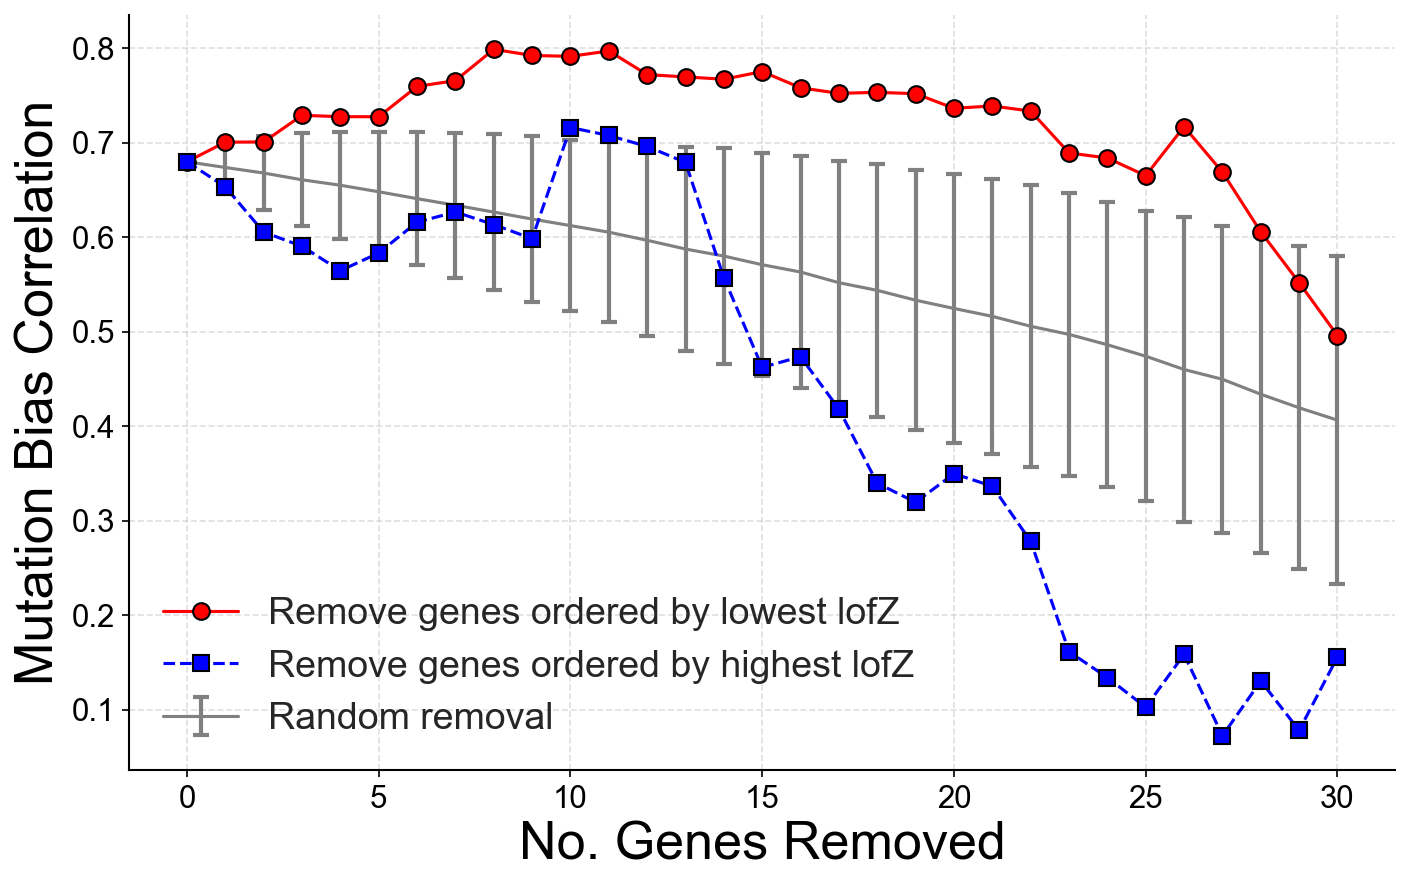

In [31]:
fig, ax = plt.subplots(dpi=150, figsize=(9.5, 6), facecolor='none')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)
plt.style.use('seaborn-v0_8-whitegrid')

# Plotting the main lines with custom markers and edge colors
ax.plot(X_LofZ, Y_LofZ_rev, label="Remove genes ordered by lowest lofZ", color="red", linestyle='-', marker='o', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)
ax.plot(X_LofZ, Y_LofZ, label="Remove genes ordered by highest lofZ", color="blue", linestyle='--', marker='s', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)

# Plotting the error bars for the random removal with custom error bar style
ax.errorbar(X_LofZ, rand_mean, yerr=rand_std, fmt='-', color="grey", ecolor='grey', elinewidth=2, capsize=4, capthick=2, label="Random removal", zorder=5)

# Adding labels, title, and legend with improved font properties
ax.set_xlabel("No. Genes Removed", fontsize=25, fontweight='normal')
ax.set_ylabel("Mutation Bias Correlation", fontsize=25, fontweight='normal')
#plt.title("Correlation vs No. Genes Removed", fontsize=16, fontweight='bold')
ax.legend(fontsize=18, loc='best', frameon=False)

# Adding grid lines with subtle customization


# Adjusting tick parameters for better readability
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

# Optimizing layout for better spacing and alignment


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_color('black')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
# Showing the plot
plt.show()


In [32]:
def moving_average(data, window_size=3):
    """
    Smooths a 1D array using a simple moving average.

    Parameters:
    -----------
    data : array-like
        Input 1D array to smooth.
    window_size : int
        Number of points to include in the moving window (must be odd for symmetry).

    Returns:
    --------
    smoothed : np.ndarray
        Smoothed array of the same length as input (with edge padding).
    """
    if window_size < 1 or window_size % 2 == 0:
        raise ValueError("window_size must be a positive odd integer.")
    
    # Create kernel and apply convolution
    kernel = np.ones(window_size) / window_size
    padded = np.pad(data, (window_size//2,), mode='edge')
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed

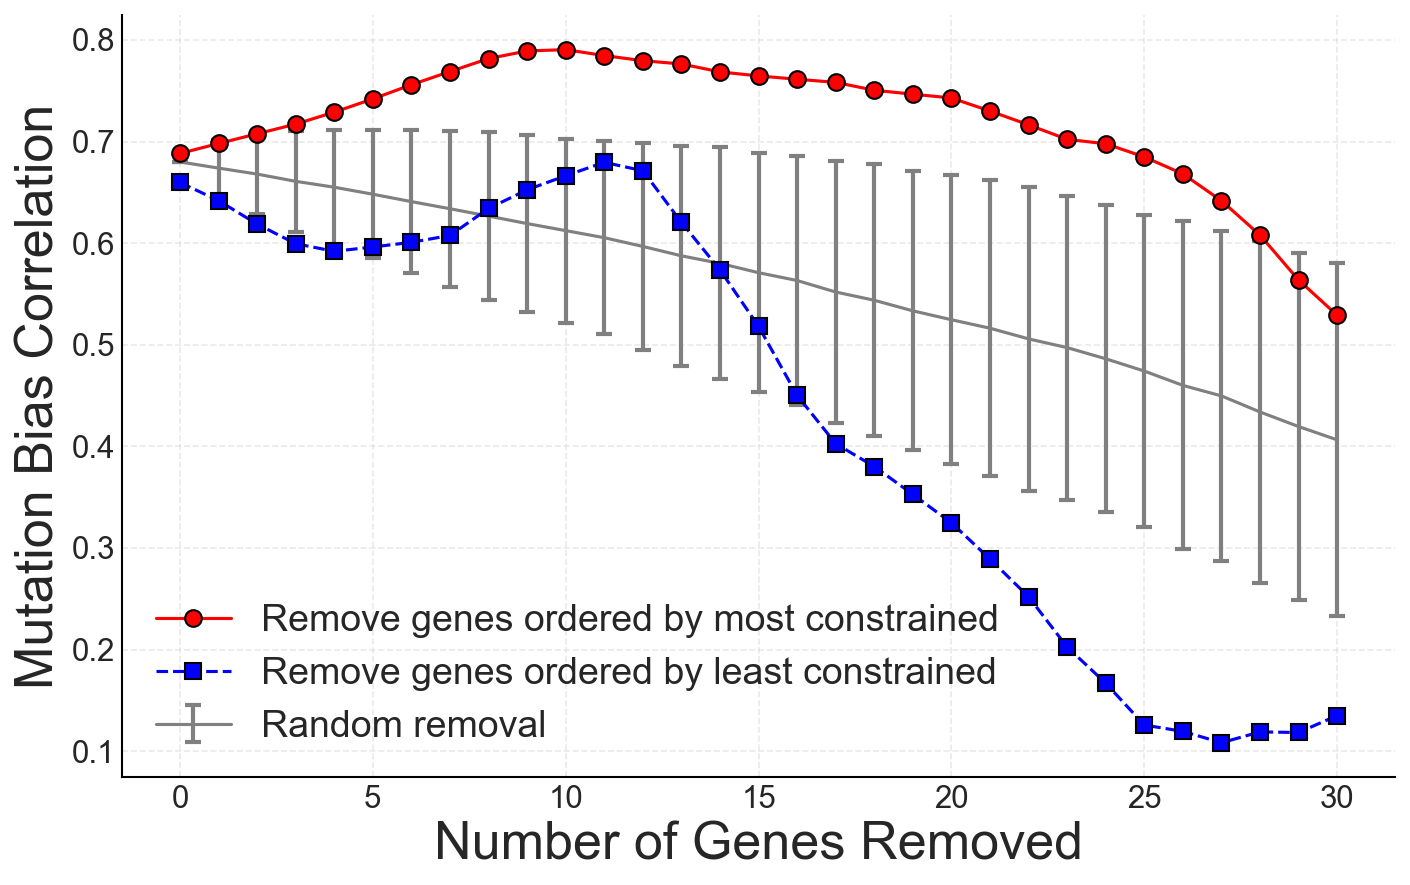

In [33]:
fig, ax = plt.subplots(dpi=150, figsize=(9.5, 6), facecolor='none')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)
plt.style.use('seaborn-v0_8-whitegrid')

# Plotting the main lines with custom markers and edge colors
window_size = 5
Y_LofZ_smooth = moving_average(Y_LofZ, window_size=window_size)
Y_LofZ_rev_smooth = moving_average(Y_LofZ_rev, window_size=window_size)
#ax.plot(X, Y_rev_smooth, label="Remove genes ordered by lowest lofZ", color="red", linestyle='-', marker='o', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)
#ax.plot(X, Y_smooth, label="Remove genes ordered by highest lofZ", color="blue", linestyle='--', marker='s', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)
ax.plot(X_LofZ, Y_LofZ_rev_smooth, label="Remove genes ordered by most constrained", color="red", linestyle='-', marker='o', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)
ax.plot(X_LofZ, Y_LofZ_smooth, label="Remove genes ordered by least constrained", color="blue", linestyle='--', marker='s', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)

# Plotting the error bars for the random removal with custom error bar style
ax.errorbar(X_LofZ, rand_mean, yerr=rand_std, fmt='-', color="grey", ecolor='grey', elinewidth=2, capsize=4, capthick=2, label="Random removal", zorder=5)

# Adding labels, title, and legend with improved font properties
ax.set_xlabel("Number of Genes Removed", fontsize=25, fontweight='normal')
ax.set_ylabel("Mutation Bias Correlation", fontsize=25, fontweight='normal')
#plt.title("Correlation vs No. Genes Removed", fontsize=16, fontweight='bold')
ax.legend(fontsize=18, loc='best', frameon=False)

# Adding grid lines with subtle customization


# Adjusting tick parameters for better readability
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

# Optimizing layout for better spacing and alignment


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_color('black')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
# Showing the plot
plt.show()


In [34]:
idx = 27
print(GetPermutationP(RandYY[:, idx], Y_LofZ[idx], greater_than=False))
print(GetPermutationP(RandYY[:, idx], Y_LofZ_rev[idx], greater_than=True))

(-2.320876597760492, 0.029970029970029972, -0.3772935656423965)
(1.3487601563842235, 0.04995004995004995, 0.21926134680733894)


In [35]:
idx = 24
print(GetPermutationP(RandYY[:, idx], Y_LofZ[idx], greater_than=False))
print(GetPermutationP(RandYY[:, idx], Y_LofZ_rev[idx], greater_than=True))

(-2.334876582892635, 0.030969030969030968, -0.3522332551141577)
(1.3100964881146102, 0.07192807192807193, 0.19763766269416344)


#### Gradually remove Genes ranked by Expression Level vs random genes, how correlation change?

In [36]:
X, Y = [],[]
for i in range(0, 31, 1):
#for i in range(1, 3, 1):
    #print(i)
    tmp_ASD_GW = dict(zip(ASD_GeneHumanExp["Entrez"].values[i:], ASD_GeneHumanExp["GW"].values[i:]))
    tmp_SCZ_GW = dict(zip(SCZ_GeneHumanExp["Entrez"].values[i:], SCZ_GeneHumanExp["GW"].values[i:]))
    
    tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW)
    tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

    tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
    tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)
    
    r,p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, efflabel="EFFECT", CTs = Neur_idx)
    
    #print(i, r)
    X.append(i)
    Y.append(r)

In [37]:
Y_rev = []
for i in range(0, 31, 1):
#for i in range(1, 3, 1):
    #print(i)
    tmp_ASD_GW = dict(zip(ASD_GeneHumanExp["Entrez"].values[::-1][i:], ASD_GeneHumanExp["GW"].values[::-1][i:]))
    tmp_SCZ_GW = dict(zip(SCZ_GeneHumanExp["Entrez"].values[::-1][i:], SCZ_GeneHumanExp["GW"].values[::-1][i:]))
    
    tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW)
    tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

    tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
    tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)
    
    r,p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, efflabel="EFFECT", CTs = Neur_idx)

    Y_rev.append(r)

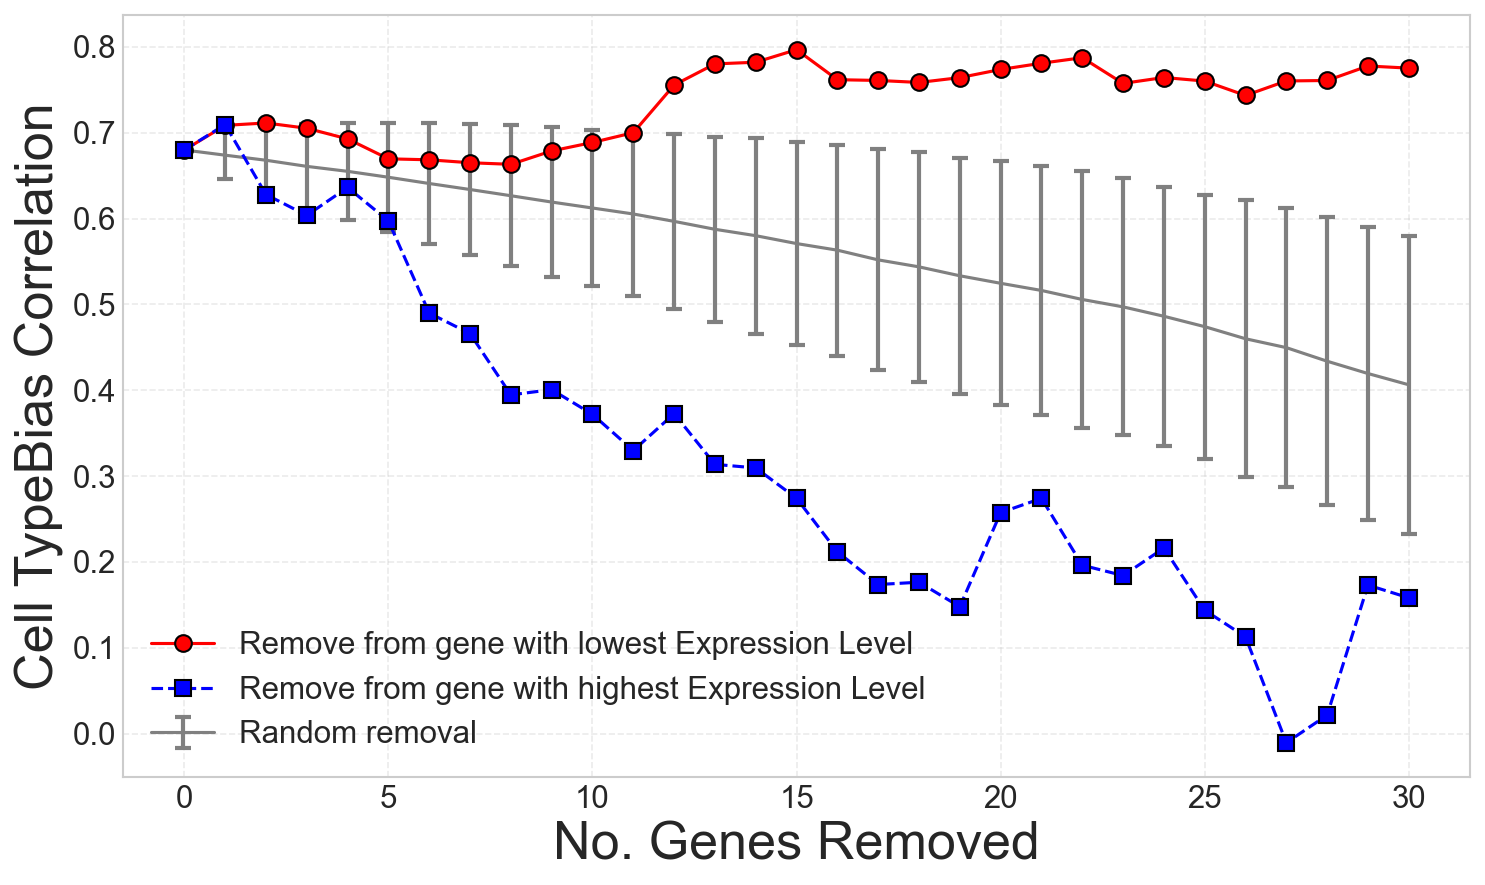

In [38]:
import matplotlib.pyplot as plt

plt.figure(dpi=150, figsize=(10, 6))

# Plotting the main lines with custom markers and edge colors
plt.plot(X, Y_rev, label="Remove from gene with lowest Expression Level", color="red", linestyle='-', marker='o', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)
plt.plot(X, Y, label="Remove from gene with highest Expression Level", color="blue", linestyle='--', marker='s', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)

# Plotting the error bars for the random removal with custom error bar style
plt.errorbar(X, rand_mean, yerr=rand_std, fmt='-', color="grey", ecolor='grey', elinewidth=2, capsize=4, capthick=2, label="Random removal", zorder=5)

# Adding labels, title, and legend with improved font properties
plt.xlabel("No. Genes Removed", fontsize=25, fontweight='normal')
plt.ylabel("Cell TypeBias Correlation", fontsize=25, fontweight='normal')
#plt.title("Correlation vs No. Genes Removed", fontsize=16, fontweight='bold')
plt.legend(fontsize=15, loc='best', frameon=False)

# Adding grid lines with subtle customization
plt.grid(True, linestyle='--', alpha=0.4)

# Adjusting tick parameters for better readability
plt.xticks(fontsize=15, fontweight='normal')
plt.yticks(fontsize=15, fontweight='normal')

# Optimizing layout for better spacing and alignment
#plt.ylim(-0.05, 0.75)
plt.tight_layout()

# Showing the plot
plt.show()


In [39]:
idx = 30
print(GetPermutationP(RandYY[:, idx], Y[idx], greater_than=False))
print(GetPermutationP(RandYY[:, idx], Y_rev[idx], greater_than=True))

(-1.4294904547859155, 0.09290709290709291, -0.24815717888395536)
(2.1247080878317814, 0.005994005994005994, 0.3688458102416796)


### BrainSpan

In [40]:
# Try Brain span
ASD_GeneBSExp = ASD_GeneLofZ.sort_values("BrainSpan", ascending=False)
SCZ_GeneBSExp = SCZ_GeneLofZ.sort_values("BrainSpan", ascending=False)

In [41]:
X_BrainSpan, Y_BrainSpan = [],[]
for i in range(0, 31, 1):
#for i in range(1, 3, 1):
    #print(i)
    tmp_ASD_GW = dict(zip(ASD_GeneBSExp["Entrez"].values[i:], ASD_GeneBSExp["GW"].values[i:]))
    tmp_SCZ_GW = dict(zip(SCZ_GeneBSExp["Entrez"].values[i:], SCZ_GeneBSExp["GW"].values[i:]))
    
    tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW)
    tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

    tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
    tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)
    
    r,p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, CTs = Neur_idx)
    
    #print(i, r)
    X_BrainSpan.append(i)
    Y_BrainSpan.append(r)

In [42]:
Y_BrainSpan_rev = []
for i in range(0, 31, 1):
#for i in range(1, 3, 1):
    #print(i)
    tmp_ASD_GW = dict(zip(ASD_GeneBSExp["Entrez"].values[::-1][i:], ASD_GeneBSExp["GW"].values[::-1][i:]))
    tmp_SCZ_GW = dict(zip(SCZ_GeneBSExp["Entrez"].values[::-1][i:], SCZ_GeneBSExp["GW"].values[::-1][i:]))
    
    tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW)
    tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

    tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
    tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)
    
    r,p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, CTs = Neur_idx)

    Y_BrainSpan_rev.append(r)

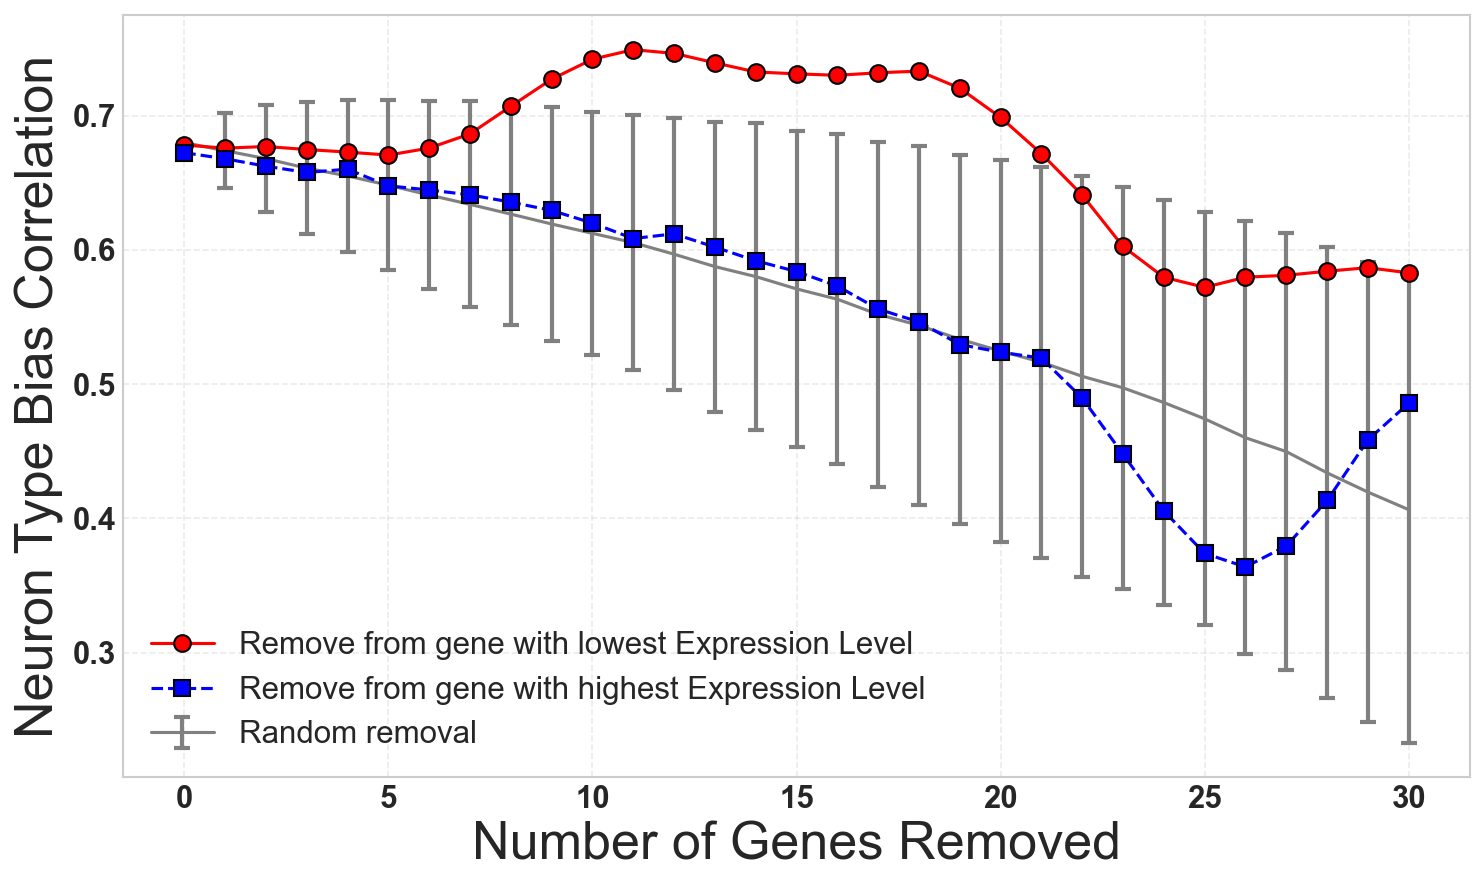

In [43]:
import matplotlib.pyplot as plt

plt.figure(dpi=150, figsize=(10, 6))

window_size = 5
Y_smooth = moving_average(Y_BrainSpan, window_size=window_size)
Y_rev_smooth = moving_average(Y_BrainSpan_rev, window_size=window_size)
# Plotting the main lines with custom markers and edge colors
plt.plot(X_BrainSpan, Y_rev_smooth, label="Remove from gene with lowest Expression Level", color="red", linestyle='-', marker='o', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)
plt.plot(X_BrainSpan, Y_smooth, label="Remove from gene with highest Expression Level", color="blue", linestyle='--', marker='s', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)

# Plotting the error bars for the random removal with custom error bar style
plt.errorbar(X_BrainSpan, rand_mean, yerr=rand_std, fmt='-', color="grey", ecolor='grey', elinewidth=2, capsize=4, capthick=2, label="Random removal", zorder=5)

# Adding labels, title, and legend with improved font properties
plt.xlabel("Number of Genes Removed", fontsize=25, fontweight='normal')
plt.ylabel("Neuron Type Bias Correlation", fontsize=25, fontweight='normal')
#plt.title("Correlation vs No. Genes Removed", fontsize=16, fontweight='bold')
plt.legend(fontsize=15, loc='best', frameon=False)

# Adding grid lines with subtle customization
plt.grid(True, linestyle='--', alpha=0.4)

# Adjusting tick parameters for better readability
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')

# Optimizing layout for better spacing and alignment
plt.tight_layout()

# Showing the plot
plt.show()


### Try LOEUF

In [44]:
X_LOEUF, Y_LOEUF = [],[]
for i in range(0, 31, 1):
#for i in range(1, 3, 1):
    #print(i)
    tmp_ASD_GW = dict(zip(ASD_Gene_LOUEF["Entrez"].values[i:], ASD_Gene_LOUEF["GW"].values[i:]))
    tmp_SCZ_GW = dict(zip(SCZ_Gene_LOUEF["Entrez"].values[i:], SCZ_Gene_LOUEF["GW"].values[i:]))
    
    tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW)
    tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

    tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
    tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)
    
    r,p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, CTs=Neur_idx)
    
    #print(i, r)
    X_LOEUF.append(i)
    Y_LOEUF.append(r)

Y_LOEUF_rev = [] # Lower LOEUF means more constrained
for i in range(0, 31, 1):
#for i in range(1, 3, 1):
    #print(i)
    tmp_ASD_GW = dict(zip(ASD_Gene_LOUEF["Entrez"].values[::-1][i:], ASD_Gene_LOUEF["GW"].values[::-1][i:]))
    tmp_SCZ_GW = dict(zip(SCZ_Gene_LOUEF["Entrez"].values[::-1][i:], SCZ_Gene_LOUEF["GW"].values[::-1][i:]))
    
    tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW )
    tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

    tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
    tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)
    
    r,p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, CTs=Neur_idx)

    Y_LOEUF_rev.append(r)

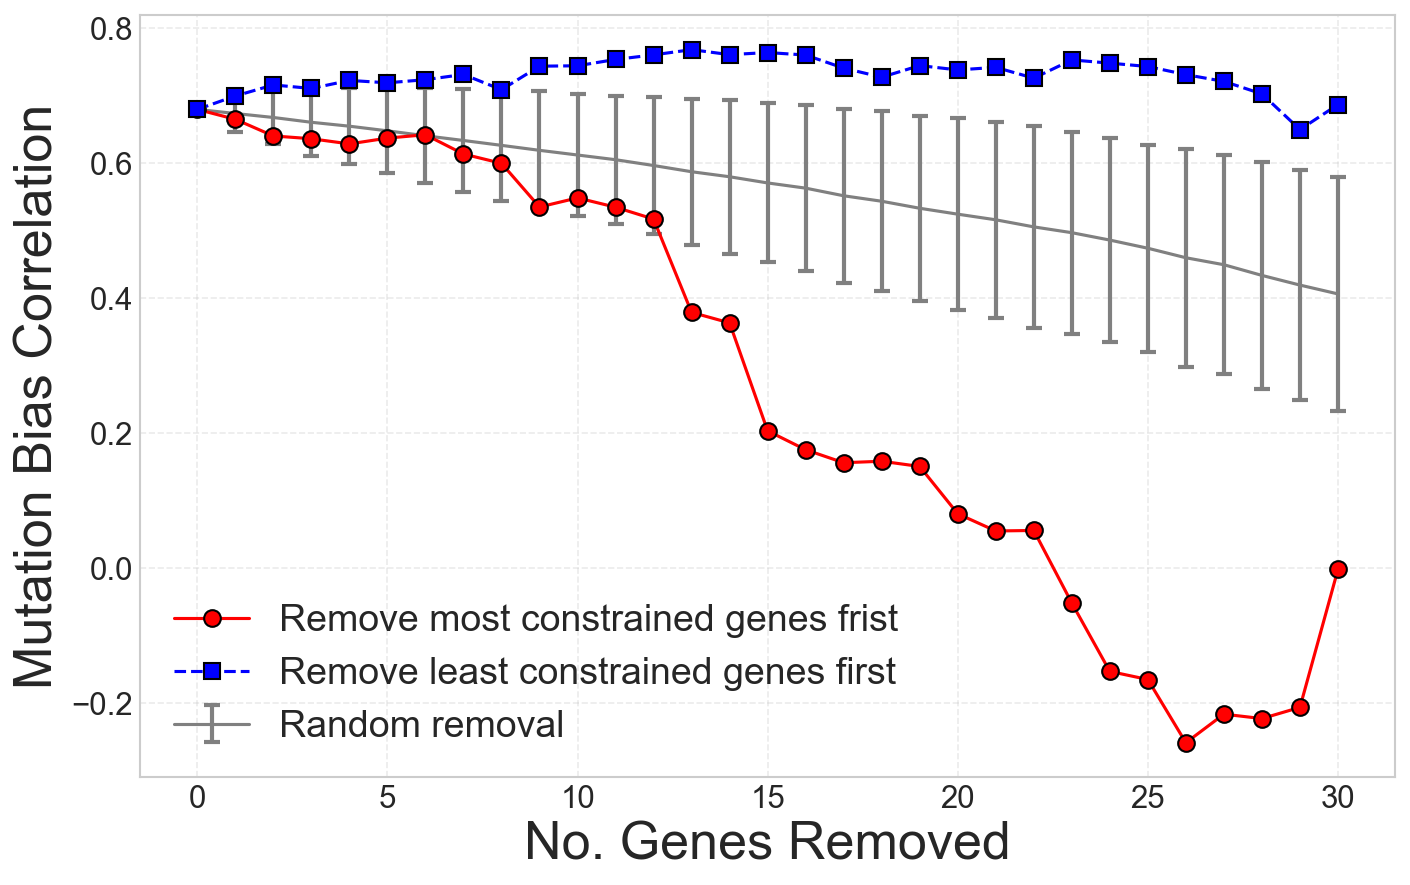

In [45]:
import matplotlib.pyplot as plt

plt.figure(dpi=150, figsize=(9.5, 6))

# Plotting the main lines with custom markers and edge colors
plt.plot(X_LOEUF , Y_LOEUF_rev, label="Remove most constrained genes frist", color="red", linestyle='-', marker='o', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)
plt.plot(X_LOEUF, Y_LOEUF, label="Remove least constrained genes first", color="blue", linestyle='--', marker='s', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)

# Plotting the error bars for the random removal with custom error bar style
plt.errorbar(X_LOEUF, rand_mean, yerr=rand_std, fmt='-', color="grey", ecolor='grey', elinewidth=2, capsize=4, capthick=2, label="Random removal", zorder=5)

# Adding labels, title, and legend with improved font properties
plt.xlabel("No. Genes Removed", fontsize=25, fontweight='normal')
plt.ylabel("Mutation Bias Correlation", fontsize=25, fontweight='normal')
#plt.title("Correlation vs No. Genes Removed", fontsize=16, fontweight='bold')
plt.legend(fontsize=18, loc='best', frameon=False)

# Adding grid lines with subtle customization
plt.grid(True, linestyle='--', alpha=0.4)

# Adjusting tick parameters for better readability
plt.xticks(fontsize=15, fontweight='normal')
plt.yticks(fontsize=15, fontweight='normal')

# Optimizing layout for better spacing and alignment
plt.tight_layout()

# Showing the plot
plt.show()


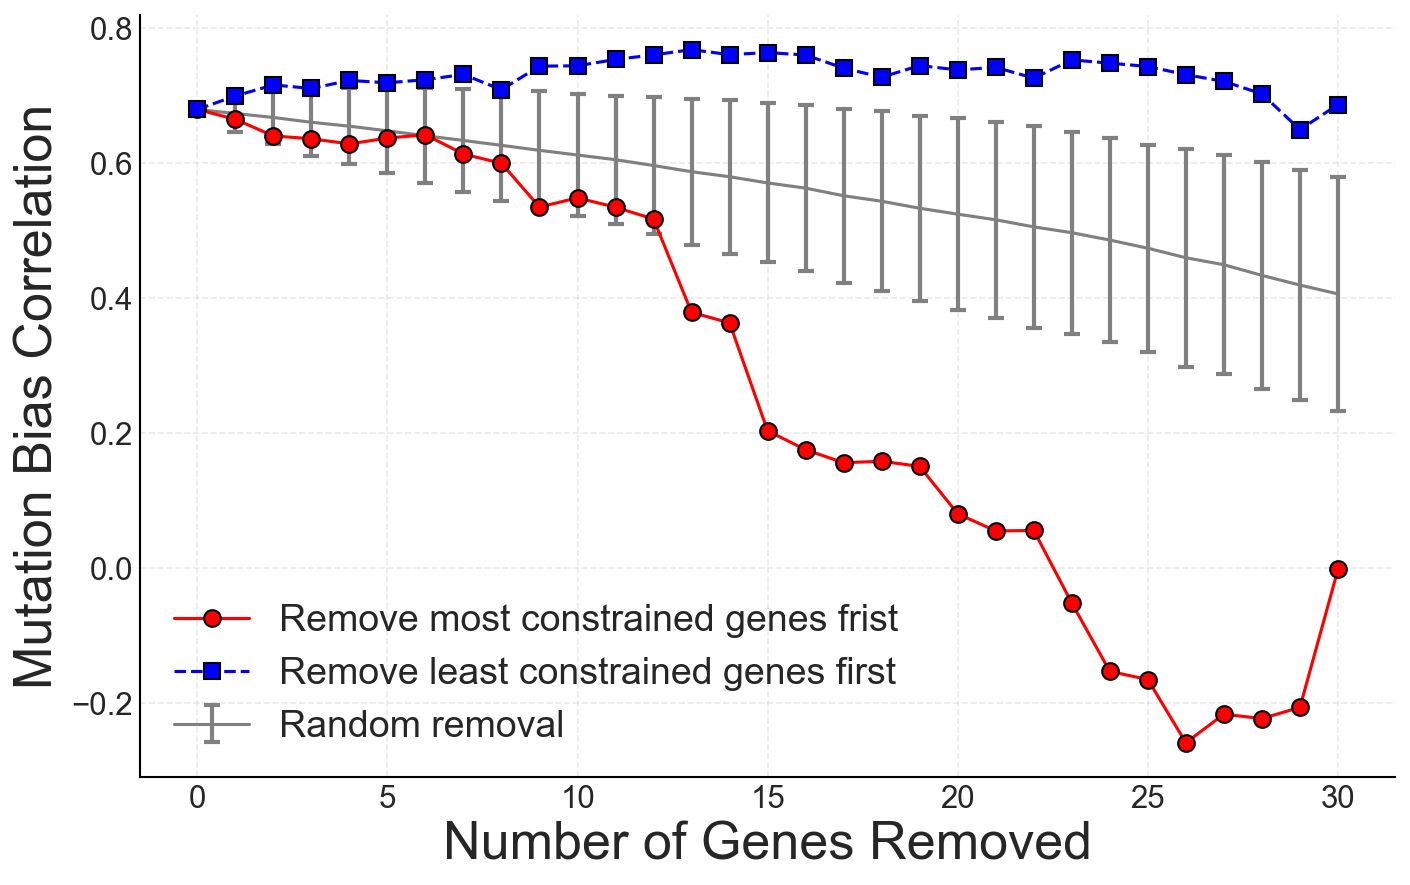

In [46]:
fig, ax = plt.subplots(dpi=150, figsize=(9.5, 6), facecolor='none')
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)
plt.style.use('seaborn-v0_8-whitegrid')

ax.plot(X_LOEUF , Y_LOEUF_rev, label="Remove most constrained genes frist", color="red", linestyle='-', marker='o', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)
ax.plot(X_LOEUF, Y_LOEUF, label="Remove least constrained genes first", color="blue", linestyle='--', marker='s', markersize=8, markeredgecolor='black', markeredgewidth=1, zorder=10)

# Plotting the error bars for the random removal with custom error bar style
ax.errorbar(X_LOEUF, rand_mean, yerr=rand_std, fmt='-', color="grey", ecolor='grey', elinewidth=2, capsize=4, capthick=2, label="Random removal", zorder=5)
# Adding labels, title, and legend with improved font properties
ax.set_xlabel("Number of Genes Removed", fontsize=25, fontweight='normal')
ax.set_ylabel("Mutation Bias Correlation", fontsize=25, fontweight='normal')
#plt.title("Correlation vs No. Genes Removed", fontsize=16, fontweight='bold')
ax.legend(fontsize=18, loc='best', frameon=False)

# Adding grid lines with subtle customization


# Adjusting tick parameters for better readability
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)

# Optimizing layout for better spacing and alignment


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['bottom'].set_color('black')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
# Showing the plot
plt.show()


In [47]:
idx = 25
print(GetPermutationP(RandYY[:, idx], Y_LOEUF[idx], greater_than=True))
print(GetPermutationP(RandYY[:, idx], Y_LOEUF_rev[idx], greater_than=False))

(1.7522783413865803, 0.01098901098901099, 0.26938482556879445)
(-4.15825671951436, 0.001998001998001998, -0.6392655975935022)


In [48]:
idx = 23
print(GetPermutationP(RandYY[:, idx], Y_LOEUF[idx], greater_than=True))
print(GetPermutationP(RandYY[:, idx], Y_LOEUF_rev[idx], greater_than=False))

(1.7119828763203386, 0.011988011988011988, 0.256116235628018)
(-3.669651639182682, 0.004995004995004995, -0.5489875961339886)


In [49]:
# Double check if splition is correct
ASD_Gene_Constrained = ASD_Gene_LOUEF[ASD_Gene_LOUEF["lof.oe_ci.upper"] < 0.2]
ASD_Gene_Unconstrained = ASD_Gene_LOUEF[ASD_Gene_LOUEF["lof.oe_ci.upper"] >= 0.2]

SCZ_Gene_Constrained = SCZ_Gene_LOUEF[SCZ_Gene_LOUEF["lof.oe_ci.upper"] < 0.5]
SCZ_Gene_Unconstrained = SCZ_Gene_LOUEF[SCZ_Gene_LOUEF["lof.oe_ci.upper"] >= 0.5]

print(len(ASD_Gene_Constrained), len(ASD_Gene_Unconstrained))
print(len(SCZ_Gene_Constrained), len(SCZ_Gene_Unconstrained))

18 24
34 27


In [50]:
tmp_ASD_GW = dict(zip(ASD_Gene_Constrained["Entrez"].values, ASD_Gene_Constrained["GW"].values))
tmp_SCZ_GW = dict(zip(SCZ_Gene_Constrained["Entrez"].values, SCZ_Gene_Constrained["GW"].values))

tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW)
tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)

r,p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, CTs=Neur_idx)
print(r, p )

0.7334609102419128 5.088528225470496e-65


In [51]:
tmp_ASD_GW = dict(zip(ASD_Gene_Unconstrained["Entrez"].values, ASD_Gene_Unconstrained["GW"].values))
tmp_SCZ_GW = dict(zip(SCZ_Gene_Unconstrained["Entrez"].values, SCZ_Gene_Unconstrained["GW"].values))

tmp_ASD_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_ASD_GW)
tmp_ASD_Bias = AnnotateCTDat(tmp_ASD_Bias, Anno)

tmp_SCZ_Bias = HumanCT_AvgZ_Weighted(HCT_Z2_MAT_HCT, tmp_SCZ_GW)
tmp_SCZ_Bias = AnnotateCTDat(tmp_SCZ_Bias, Anno)

r,p = GetSingeCellBiasCorr(tmp_ASD_Bias, tmp_SCZ_Bias, CTs=Neur_idx)
print(r, p ) # Constrained genes are more similar, Unconstrained genes are more different

-0.2691242885037808 1.0760359565254293e-07
